# Quantum Fourier Transform
* QFT is a unitary transform. 
* Let $N = 2^n$ and $\omega = e^{\frac{2\pi i}{N}}$
* For $n = 2$, $\omega = i$
$$QFT_N = \frac{1}{\sqrt{2^n}}\sum_{x = 0}^{2^n-1}\sum_{y = 0}^{2^n-1}\omega^{xy}|x\rangle\langle y|$$
$$QFT_N|y\rangle = \frac{1}{\sqrt{2^n}}\sum_{x = 0}^{2^n-1}\omega^{xy}|x\rangle$$
* For $N = 2$, $n = 1, \omega = e^{\frac{2\pi i}{2}} = -1$
$$QFT_2 = \frac{1}{\sqrt{2}}\sum_{x = 0}^{1}\sum_{y = 0}^{1}\omega^{xy}|x\rangle\langle y|=\frac{1}{\sqrt{2}}(|0\rangle\langle 0| + |0\rangle\langle 1| + |1\rangle\langle 0| - |1\rangle\langle 1|)=H$$

## Fast Fourier trick
* Consider $x$ and $y$ to be bit strings representing states. $$\begin{align}|x\rangle|a\rangle &= |2x + a\rangle\\|b\rangle|y\rangle &= |2^{n-1}b + y\rangle\end{align}$$
* Recursive backtracking ($n\geq 2$) $$\begin{align*}
QFT_n |2x + a\rangle = QFT_n|x\rangle|a\rangle &= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1\omega^{(2x+a)(2^{n-1}b + y)}|b2^{n-1} + y\rangle\\
&= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1\omega^{(2^n xb+2xy+2^{n-1}ab + ay)}|b\rangle|y\rangle\\
&= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1\omega^{2^n xb}\omega^{2xy}\omega^{2^{n-1}ab}\omega^{ay}|b\rangle|y\rangle\\
&= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1(-1)^{ab}\omega^{2xy}\omega^{ay}|b\rangle|y\rangle\\
&= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1(-1)^{ab}\omega^{2xy}\omega^{ay}|b\rangle|y\rangle\\
&= \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^{n-1} -1}\sum_{b=0}^1(-1)^{ab}\omega^{2xy}\omega^{ay}SWAP_{n-1,1}|y\rangle|b\rangle\\
&= SWAP_{n-1,1}\frac{1}{\sqrt{2^{n-1}}}\sum_{y=0}^{2^{n-1} -1}\omega^{2xy}\omega^{ay}|y\rangle\frac{1}{\sqrt{2}}\sum_{b=0}^1(-1)^{ab}|b\rangle\\
&= SWAP_{n-1,1}\frac{1}{\sqrt{2^{n-1}}}\sum_{y=0}^{2^{n-1} -1}\omega^{2xy}\omega^{ay}|y\rangle H|a\rangle\\
&= SWAP_{n-1,1}\cdot(I^{\otimes n-1}\otimes H)\frac{1}{\sqrt{2^{n-1}}}\sum_{y=0}^{2^{n-1} -1}\omega^{2xy}\omega^{ay}|y\rangle |a\rangle\\
&= SWAP_{n-1,1}\cdot(I^{\otimes n-1}\otimes H)\frac{1}{\sqrt{2^{n-1}}}\sum_{y=0}^{2^{n-1} -1}\omega^{2xy}CR_n|y\rangle |a\rangle\\
&= SWAP_{n-1,1}\cdot(I^{\otimes n-1}\otimes H)\cdot CR_{n}\cdot (QFT_{n-1}|x\rangle) |a\rangle\\
\end{align*}$$
* $QFT_n = SWAP_{n-1,1}\cdot(I^{\otimes n-1}\otimes H)\cdot CR_{n}\cdot (QFT_{n-1}\otimes I)$

## Phase gates
* The gates $CR_n$ act as follows: $$|y\rangle|a\rangle\to \omega^{ay}|y\rangle|a\rangle$$
$$\begin{align*}
|y\rangle|a\rangle&\to \omega^{ay}|y\rangle|a\rangle\\
                  &= \omega^{a(\sum_{k=0}^{n-2}y_k2^k)}|y_{n-2}2^{n-2}+\cdots+y_0\rangle|a\rangle\\
                  &= \otimes_{k=0}^{n-2}(\omega^{a\cdot 2^ky_k}|y_k\rangle)|a\rangle
\end{align*}$$
* With $n\geq 2, 0\leq k\leq n-2$, we can interpret that $R_k$ acts on $|a\rangle$ controlled by $|y_k\rangle$. $$R_k = \begin{bmatrix}1 & 0\\ 0 & \omega^{2^k}\end{bmatrix}$$
* In terms of $R_k$ gates, we can obtain $CR_n$ gate as $R_k$ gates controlled by $kth$ bit in $y$ for every $k$.

In [22]:
# Create R gates
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import array_to_latex
import numpy as np
def Rk(k, n):
    phase = 1j * 2 * np.pi / (2 ** (n - k))
    if (n < 2) or (k < 0 ) or (k > n - 2):
        phase = 0
    matrix = [[1, 0], [0, np.exp(phase)]]
    # print(matrix)
    lab = f"$R_{n:d}^{k:d}$"
    gate = UnitaryGate(matrix, label=lab)
    gate.name = f"R{k:d}"
    display(array_to_latex(gate.to_matrix()))
    return gate

In [23]:
Rk(3,5)
Rk(0,2)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Instruction(name='R0', num_qubits=1, num_clbits=0, params=[array([[1.000000e+00+0.j, 0.000000e+00+0.j],
       [0.000000e+00+0.j, 6.123234e-17+1.j]])])

<IPython.core.display.Latex object>

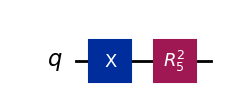

<IPython.core.display.Latex object>

In [24]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(1)
qc.x(0)
newQc = qc.compose(Rk(2,5))
display(newQc.draw("mpl"))
display(Statevector(newQc).draw("latex"))


<IPython.core.display.Latex object>

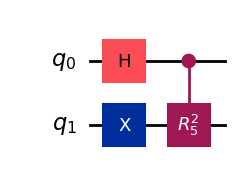

<IPython.core.display.Latex object>

In [25]:
# Controlled Rk gates
qcc = QuantumCircuit(2)
qcc.h(0)
qcc.x(1)
cRk = Rk(2,5).control()
newQcc = qcc.compose(cRk)
display(newQcc.draw("mpl"))
display(Statevector(newQcc).draw("latex"))

0


<IPython.core.display.Latex object>

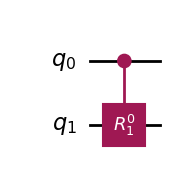

Instruction(name='CR2', num_qubits=2, num_clbits=0, params=[])

In [26]:
# Construct CR_n gate: n control qubits and one target qubit |x>|a> here x is control and a is target
def CRn(num_qubits):
    if num_qubits < 2:
        qc0 = QuantumCircuit(num_qubits)
        return qc0
    # n = num_qubits - 2
    qc = QuantumCircuit(num_qubits)
    for k in range(num_qubits - 1):
        print(k)
        rk = Rk(k, num_qubits - 1)
        crk = rk.control()
        qc.compose(crk, [0, k + 1], inplace=True)
        # display(qc.draw("mpl"))
    display(qc.draw("mpl"))
    crn = qc.to_gate(label=f"$CR_{num_qubits:d}$")
    crn.name = f"CR{num_qubits:d}"
    return crn

CRn(2)


## Swap gate
* We need $|y\rangle|b\rangle\to |b\rangle|y\rangle$
* We can think of it as cyclic shift.

4


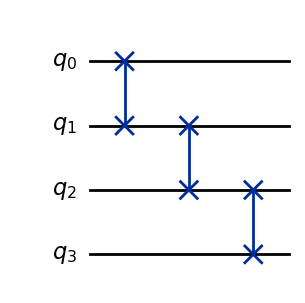

Instruction(name='Swapn', num_qubits=4, num_clbits=0, params=[])

In [27]:
from qiskit.circuit.library import SwapGate
def swapn(num_qubits):
    print(num_qubits)
    if num_qubits == 2:
        qc2 = QuantumCircuit(num_qubits)
        qc2.swap(0, 1)
        return qc2
    n = num_qubits - 1
    qc = QuantumCircuit(num_qubits)
    for k in range(n):
        qc.swap(k, k + 1)
    display(qc.draw("mpl"))
    lab = f"$Swap_1^{num_qubits:d}$"
    gate = qc.to_gate(label=lab)
    gate.name = "Swapn"
    return gate

swapn(4)

4


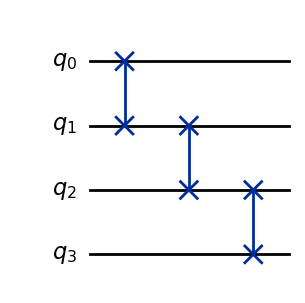

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

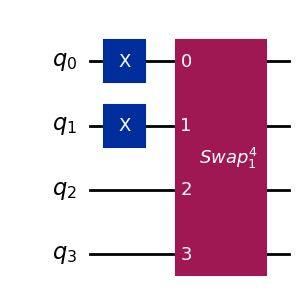

In [28]:
qc1 = QuantumCircuit(4)
qc1.x(0)
qc1.x(1)
sn = swapn(4)
display(Statevector(qc1).draw("latex"))
qc2 = qc1.compose(sn)
display(Statevector(qc2).draw("latex"))
display(qc2.draw("mpl"))


* Now we have all the ingredients for recursive QFT.

In [29]:
from qiskit.circuit.library import HGate
def QFT(num_qubits):
    if num_qubits == 1:
        qc1 = QuantumCircuit(1)
        qc1.h(0)
        return qc1
    else:
        qc = QuantumCircuit(num_qubits)
        qft = QFT(num_qubits - 1)
        qc.compose(qft, list(range(1,num_qubits)), inplace=True)
        crn = CRn(num_qubits)
        swn = swapn(num_qubits)
        qc.compose(crn, inplace=True)
        qc.h(0)
        qc.compose(swn, inplace=True)
        display(qc.draw("mpl"))
        return qc

0


<IPython.core.display.Latex object>

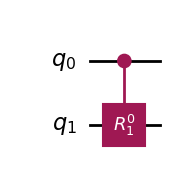

2


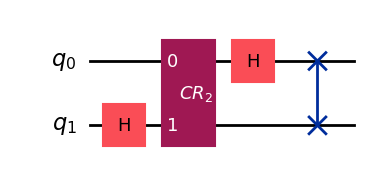

0


<IPython.core.display.Latex object>

1


<IPython.core.display.Latex object>

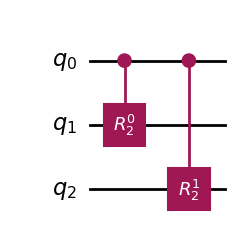

3


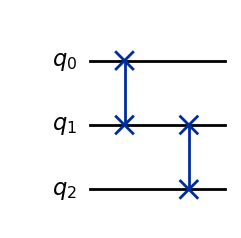

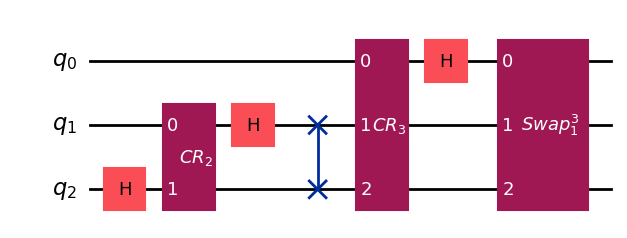

0


<IPython.core.display.Latex object>

1


<IPython.core.display.Latex object>

2


<IPython.core.display.Latex object>

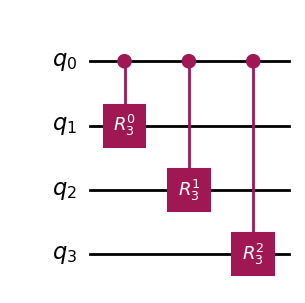

4


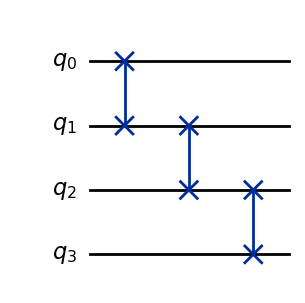

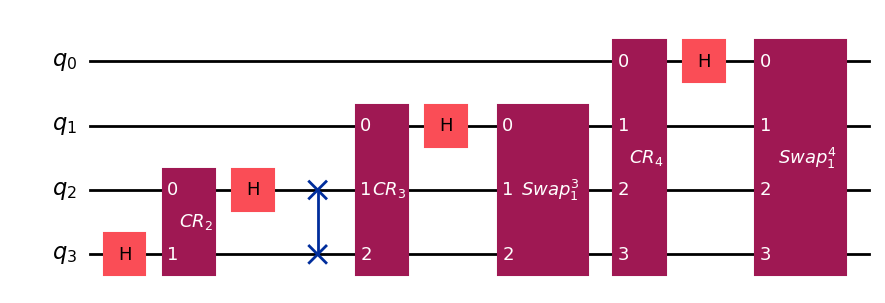

In [30]:
QFT(4)